### **Load Dependencies**

In [1]:
import time
from prompts import *
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
from IPython.display import Markdown, display, Image

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

- **Load Docs**

In [2]:
docs = (
    PyPDFLoader("./docs/Company_Policies.pdf").load()
    + PyPDFLoader("./docs/Company_Profile.pdf").load()
    + PyPDFLoader("./docs/Product_and_Pricing.pdf").load()
)

- **Split Docs into Chunks**

In [3]:
chunks = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=150
).split_documents(docs)

- **Embed Chunks and Create Retriever**

In [4]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})

- **Create LLM**

In [5]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

### **Graph Building**

- **Graph State**

In [93]:
class State(TypedDict):
    question: str
    need_retrieval: Literal[True, False]

    docs: List[Document]
    relevant_docs: List[Document]
    irrelevant_docs: List[Document]

    answer: str

#### **Decide Retrieval Node**
- Decide whether retrieval is necessary for answering the question

In [94]:
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="Whether the agent should perform retrieval to answer the question."
    )

In [95]:
def decide_retrieval(state: State) -> dict:
    """ This function uses the LLM to decide whether retrieval is necessary to answer the question."""

    should_retrieve_llm = llm.with_structured_output(RetrieveDecision)
    decision: RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_prompt(question=state["question"])
    )
    
    return { "need_retrieval" : decision.should_retrieve }

In [96]:
decision = decide_retrieval({"question": "What is the company policy?"})
decision

{'need_retrieval': True}

#### **Generate Answer**
- Generate a direct answer to the question.

In [97]:
def generate_direct(state: State) -> dict:
    """ This function uses the LLM to generate a direct answer to the question."""

    answer = llm.invoke(
        direct_generation_prompt.format_prompt(question=state["question"])
    )
    return {"answer": answer.content}

In [98]:
answer = generate_direct({ "question" : "What is Machine Learning?" })['answer']
# display(Markdown(answer))

#### **Retrieve Docs**
- Retrieve docs using the retriever

In [99]:
def retrieve(state: State) -> dict:
    """ This function performs retrieval using the retriever and returns the retrieved documents."""
    retrieved_docs = retriever.invoke(state["question"])
    return {"docs": retrieved_docs}

In [118]:
retrieved_docs = retrieve({"question": "Who is the CEO of NexaAI?"})

In [119]:
display(Markdown(retrieved_docs['docs'][0].page_content))

Founder
Aarav Mehta founded NexaAI after over 10 years of experience in enterprise data platforms and
cloud infrastructure.
He previously worked with global consulting firms where he led multiple large-scale digital
transformation projects.
Leadership Team
The leadership team brings experience across AI engineering, product management, and business
operations.

Aarav Mehta – CEO & Founder

Riya Kapoor – CTO (Distributed systems & AI platforms)

Kunal Sharma – Head of Product

Neha Verma – Head of Operations & HR

Siddharth Rao – Head of Sales & Partnerships

#### **Decide Relevance**
- Decide whether a retrieved document is relevant to answer the question

In [120]:
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True if the document helps answer the question, else False."
    )

def decide_relevance(state: State) -> dict:
    """ This function uses the LLM to decide whether a retrieved document is relevant to answer the question."""

    relevance_llm = llm.with_structured_output(RelevanceDecision)
    
    relevant_docs: List[Document] = []
    irrelevant_docs: List[Document] = []

    for doc in state["docs"]:
        decision: RelevanceDecision = relevance_llm.invoke(
            is_relevant_prompt.format_messages(
                question=state["question"],
                document=doc.page_content
            )
        )

        if decision.is_relevant:
            relevant_docs.append(doc)
        else:
            irrelevant_docs.append(doc)

    return {"relevant_docs": relevant_docs, "irrelevant_docs": irrelevant_docs}

In [121]:
relevant_docs = decide_relevance({
    "question": "Who is the CEO of NexaAI",
    "docs": retrieved_docs["docs"]
})

In [122]:
relevant_docs['relevant_docs']

[Document(id='286af2a6-c6bc-4b71-8e26-ff5c694f5aa7', metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-14T13:07:17+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-14T13:07:17+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': './docs/Company_Profile.pdf', 'total_pages': 2, 'page': 1, 'page_label': '2'}, page_content='Founder\nAarav Mehta founded NexaAI after over 10 years of experience in enterprise data platforms and\ncloud infrastructure.\nHe previously worked with global consulting firms where he led multiple large-scale digital\ntransformation projects.\nLeadership Team\nThe leadership team brings experience across AI engineering, product management, and business\noperations.\n\x7f\nAarav Mehta – CEO & Founder\n\x7f\nRiya Kapoor – CTO (Distributed systems & AI platforms)\n\x7f\nKunal Sharma – Head of Product\n\x7f\nNeha Verma – Head of Operations & HR\n

In [123]:
len(retrieved_docs['docs'])

4

In [124]:
len(relevant_docs['irrelevant_docs'])

3

#### **Router**
- If retrieval is needed, perform retrieval. Otherwise, generate a direct answer.

In [109]:
def router(state: State) -> str:
    """ This function routes the state to the appropriate function based on whether retrieval is needed or not."""
    
    if state["need_retrieval"]:
        return "need_retrieval"
    else:
        return "generate_direct"

#### **Graph Building**

In [110]:
# State graph construction
builder = StateGraph(State)

# Adding nodes
builder.add_node("decide_retrieval", decide_retrieval)
builder.add_node("retrieve", retrieve)
builder.add_node("generate_answer", generate_direct)
builder.add_node("decide_relevance", decide_relevance)

# Adding edges
builder.add_edge(START, "decide_retrieval")

builder.add_conditional_edges(
    "decide_retrieval", router,
    {
        "need_retrieval": "retrieve",
        "generate_direct": "generate_answer"
    }
)

builder.add_edge("retrieve", "decide_relevance")
builder.add_edge("generate_answer", END)
builder.add_edge("decide_relevance", END)

# Compile the graph
rag = builder.compile()

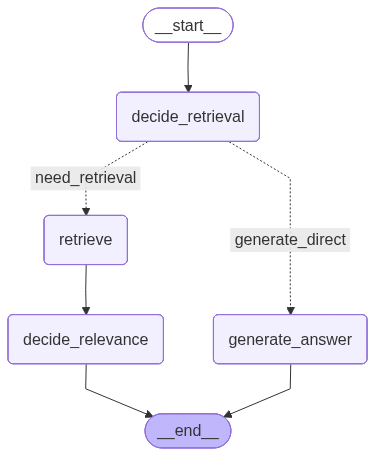

In [111]:
display(Image(rag.get_graph().draw_mermaid_png()))

#### **Test Graph**

In [114]:
result = rag.invoke(
    {
        "question": "Who is the CEO of NexaAI",
    }
)

In [115]:
result.keys()

dict_keys(['question', 'need_retrieval', 'docs', 'relevant_docs', 'irrelevant_docs'])

In [86]:
result['need_retrieval']

True

In [116]:
for doc in result['docs']:
    display(Markdown(f"**Source:** {doc.metadata['source']}"))
    display(Markdown(doc.page_content))
    display(Markdown("*"*150))

**Source:** ./docs/Company_Profile.pdf

Founder
Aarav Mehta founded NexaAI after over 10 years of experience in enterprise data platforms and
cloud infrastructure.
He previously worked with global consulting firms where he led multiple large-scale digital
transformation projects.
Leadership Team
The leadership team brings experience across AI engineering, product management, and business
operations.

Aarav Mehta – CEO & Founder

Riya Kapoor – CTO (Distributed systems & AI platforms)

Kunal Sharma – Head of Product

Neha Verma – Head of Operations & HR

Siddharth Rao – Head of Sales & Partnerships

******************************************************************************************************************************************************

**Source:** ./docs/Company_Profile.pdf

NexaAI Solutions – Company Profile
Company Overview
NexaAI Solutions Pvt. Ltd. is a business-focused artificial intelligence company founded in 2021.
The company specializes in building enterprise-ready AI systems for knowledge management,
analytics, and automation.
NexaAI primarily serves mid-sized and large organizations across technology, finance, healthcare,
and education sectors.

Founded: 2021

Headquarters: Bengaluru, India

Employees: 85+

Operating Regions: India, Southeast Asia, Europe
Vision

...

NexaAI Solutions – Products & Pricing
Product Portfolio Overview
NexaAI offers a modular suite of enterprise AI products designed to help organizations manage
knowledge, analyze business data, automate customer interactions, and enforce AI governance.
Each product can be used independently or deployed as part of an integrated AI platform.
NexaChat – Internal Knowledge Assistant
NexaChat is an AI-powered internal assistant that allows employees to query company documents,
policies, reports, and knowledge bases using natural language.

******************************************************************************************************************************************************

**Source:** ./docs/Product_and_Pricing.pdf

NexaInsight – Business Analytics & Reporting
NexaInsight helps leadership and business teams analyze structured business data using natural
language queries instead of traditional dashboards.
It connects with internal databases and BI tools to generate explainable insights.

Natural language querying over structured data

Automated KPI summaries and trend analysis

Scheduled weekly and monthly reports

Export to PDF and Excel

Role-based visibility for leadership and managers
NexaSupport – Customer Support Automation

******************************************************************************************************************************************************

In [117]:
for doc in result['relevant_docs']:
    display(Markdown(f"**Source:** {doc.metadata['source']}"))
    display(Markdown(doc.page_content))
    display(Markdown("*"*150))

**Source:** ./docs/Company_Profile.pdf

Founder
Aarav Mehta founded NexaAI after over 10 years of experience in enterprise data platforms and
cloud infrastructure.
He previously worked with global consulting firms where he led multiple large-scale digital
transformation projects.
Leadership Team
The leadership team brings experience across AI engineering, product management, and business
operations.

Aarav Mehta – CEO & Founder

Riya Kapoor – CTO (Distributed systems & AI platforms)

Kunal Sharma – Head of Product

Neha Verma – Head of Operations & HR

Siddharth Rao – Head of Sales & Partnerships

******************************************************************************************************************************************************